# Was recovery quality really more predictive of 400m performance than training volume?

**The question.** My CV currently claims that on 18 months of personal race and training data,
(a) a model predicted 400m race times with **R² = 0.84**, and (b) **recovery quality was 2.3×
more predictive of performance than training volume**. This notebook re-derives both claims
from the actual data with methodology I would be willing to defend in an interview, and reports
whatever it finds — the CV gets updated to match the analysis, not the other way around.

**The stakes.** These numbers are portfolio evidence. A reviewer who catches an inflated claim
loses trust in everything else, so rigor and honesty beat impressive numbers throughout.

**How to run this.** By default the notebook uses the private training database
(`~/data/optimalathlete.db`), which is never committed. Set `USE_SYNTHETIC=1` to run
end-to-end on the repo's seeded synthetic data generator instead (that is what CI does).
Committed outputs come from the real-data run; only aggregates and plots are shown.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RNG = np.random.default_rng(7)

# Locate repo root (notebook lives in analysis/)
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "setup_db.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate repo root containing setup_db.py")
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

FIG_DIR = REPO_ROOT / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

USE_SYNTHETIC = os.environ.get("USE_SYNTHETIC", "").lower() in {"1", "true", "yes"}

from sqlalchemy import create_engine

if USE_SYNTHETIC:
    import random as _random
    import tempfile

    from sqlalchemy.orm import sessionmaker

    from data_loader import generate_synthetic_data
    from setup_db import Base

    _random.seed(7)
    db_path = Path(tempfile.mkdtemp()) / "synthetic.db"
    engine = create_engine(f"sqlite:///{db_path}")
    Base.metadata.create_all(engine)
    _s = sessionmaker(bind=engine)()
    generate_synthetic_data(_s, num_athletes=5, days_of_data=240)
    _s.close()
    MODE = "SYNTHETIC (seeded demo data — numbers below are NOT about any real athlete)"
else:
    db_path = Path.home() / "data" / "optimalathlete.db"
    if not db_path.exists():
        raise FileNotFoundError(
            f"Private database not found at {db_path}. This notebook does not silently "
            "fall back to synthetic data: set USE_SYNTHETIC=1 explicitly to run on the "
            "seeded synthetic generator instead."
        )
    # Read-only: the analysis must never mutate the private database.
    engine = create_engine(f"sqlite:///file:{db_path}?mode=ro&uri=true")
    MODE = "REAL (private database, read-only)"

print(f"Mode: {MODE}")

athletes = pd.read_sql("SELECT * FROM athletes", engine)
sessions = pd.read_sql("SELECT * FROM training_sessions", engine)
metrics = pd.read_sql("SELECT * FROM performance_metrics", engine)
races = pd.read_sql("SELECT * FROM race_results", engine)
for df in (sessions, races):
    df["date"] = pd.to_datetime(df["date"])
print(f"Loaded {len(athletes)} athletes, {len(sessions)} sessions, "
      f"{len(metrics)} metric records, {len(races)} races")

Mode: REAL (private database, read-only)
Loaded 5 athletes, 713 sessions, 652 metric records, 29 races


## 1. Data audit — what is actually in this database?

Before any modeling: what data exists, over what period, and can it support the claims?
The CV says "18 months of personal race and training data", so the first checks are the
date ranges, the race sample size, the recovery and volume variables available, and
missingness. The audit below runs identically in both modes.

In [2]:
sess_m = sessions.merge(metrics, left_on="id", right_on="session_id", how="left")

audit_rows = []
for _, a in athletes.iterrows():
    s = sess_m[sess_m["athlete_id"] == a["id"]]
    r = races[races["athlete_id"] == a["id"]]
    audit_rows.append({
        "athlete_id": a["id"],
        "sessions": len(s),
        "sessions_with_metrics": int(s["session_id"].notna().sum()),
        "first_session": s["date"].min().date() if len(s) else None,
        "last_session": s["date"].max().date() if len(s) else None,
        "races": len(r),
        "first_race": r["date"].min().date() if len(r) else None,
        "last_race": r["date"].max().date() if len(r) else None,
        "span_months": round((s["date"].max() - s["date"].min()).days / 30.4, 1) if len(s) else 0,
    })
audit = pd.DataFrame(audit_rows)
display(audit)

# Recovery / volume variables available per session record
recovery_vars = ["hrv_score", "sleep_hours", "sleep_quality", "fatigue_level",
                 "soreness_level", "wellness_score", "resting_heart_rate"]
volume_vars = ["duration_minutes", "intensity_rpe"]
missing = sess_m[recovery_vars + volume_vars].isna().mean().round(3).rename("missing_fraction")
display(missing.to_frame())

primary_athlete = int(races["athlete_id"].value_counts().idxmax())
print(f"Primary athlete for the analysis (most races): athlete_id={primary_athlete}")

,athlete_id,sessions,sessions_with_metrics,first_session,last_session,races,first_race,last_race,span_months
0,1,149,135,2025-10-03,2026-04-01,15,2025-06-14,2026-03-22,5.9
1,2,145,134,2025-10-03,2026-04-01,4,2025-12-08,2026-03-22,5.9
2,3,142,131,2025-10-04,2026-04-01,3,2025-11-07,2026-03-30,5.9
3,4,136,126,2025-10-03,2026-03-30,4,2025-11-08,2025-12-14,5.9
4,5,141,126,2025-10-03,2026-04-01,3,2025-12-21,2026-03-28,5.9


,missing_fraction
hrv_score,0.086
sleep_hours,0.086
sleep_quality,0.086
fatigue_level,0.086
soreness_level,0.086
wellness_score,0.086
resting_heart_rate,0.086
duration_minutes,0.000
intensity_rpe,0.000


Primary athlete for the analysis (most races): athlete_id=1


### 1b. Provenance battery — is this data what it claims to be?

The repo contains a synthetic-data generator (`data_loader.py`) that historically wrote to
this same database path, and a script (`add_real_data.py`) that mixed real race results with
*generated* training sessions. So before trusting any conclusion, the data must prove its own
provenance. The checks below look for statistical fingerprints of the generator:

1. **Full-precision race times.** The generator produces times like `48.1100939377…`;
   hand-entered real results have two decimals.
2. **Bounded, integer HRV.** The generator draws `int(base × uniform(0.9, 1.1))` — a tight
   ±10% integer band with no drift.
3. **No day-to-day autocorrelation.** Real physiology (HRV, sleep, fatigue) is autocorrelated;
   the generator draws each day independently, so lag-1 autocorrelation ≈ 0.
4. **Exact generator window.** `data_loader.py` writes sessions spanning exactly its
   `days_of_data` parameter (default 180) ending on the run date.
5. **Known real races.** `add_real_data.py` documents 8 real 2025 results
   (46.95–48.02 s at named international venues); are they present?

In [3]:
def lag1_autocorr(series):
    x = series.dropna().to_numpy(dtype=float)
    if len(x) < 3 or np.std(x) == 0:
        return np.nan
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])

pa_sess = sess_m[sess_m["athlete_id"] == primary_athlete].sort_values("date")
pa_races = races[races["athlete_id"] == primary_athlete].sort_values("date")

checks = []

# 1. full-precision race times (synthetic signature)
n_fullprec = int(sum(len(repr(t).split(".")[-1]) > 4 for t in pa_races["time_seconds"]))
checks.append(("full-precision race times (generator signature)",
               f"{n_fullprec}/{len(pa_races)} races", n_fullprec > 0))

# 2. HRV integer band
hrv = pa_sess["hrv_score"].dropna()
band = (hrv.max() - hrv.min()) / hrv.mean() if len(hrv) else np.nan
checks.append(("HRV confined to ±10% integer band (generator signature)",
               f"range {hrv.min():.0f}–{hrv.max():.0f}, rel. width {band:.2f}",
               bool(band < 0.25)))

# 3. lag-1 autocorrelation of daily recovery metrics
acs = {v: lag1_autocorr(pa_sess[v]) for v in ["hrv_score", "sleep_hours", "fatigue_level"]}
checks.append(("recovery metrics ~uncorrelated day-to-day (generator signature)",
               ", ".join(f"{k} r={v:.2f}" for k, v in acs.items()),
               all(abs(v) < 0.2 for v in acs.values() if not np.isnan(v))))

# 4. exact generator window
span_days = (pa_sess["date"].max() - pa_sess["date"].min()).days
checks.append(("session span matches a single generator run window",
               f"{span_days} days ending {pa_sess['date'].max().date()}",
               span_days in range(170, 250)))

# 5. known real 2025 races present?
known_real = {47.68, 46.95, 47.37, 47.46, 48.02, 47.44, 47.85}
present = known_real & set(round(t, 2) for t in pa_races["time_seconds"])
checks.append(("documented real 2025 races present in DB",
               f"{len(present)}/{len(known_real)} found", len(present) == 0))

prov = pd.DataFrame(checks, columns=["check", "evidence", "consistent_with_synthetic"])
display(prov)
n_flags = int(prov["consistent_with_synthetic"].sum())
print(f"{n_flags}/{len(prov)} checks consistent with synthetic-generator origin")

,check,evidence,consistent_with_synthetic
0,full-precision race times (generator signature),4/15 races,True
1,HRV confined to ±10% integer band (generator s...,"range 49–60, rel. width 0.20",True
2,recovery metrics ~uncorrelated day-to-day (gen...,"hrv_score r=-0.07, sleep_hours r=0.10, fatigue...",True
3,session span matches a single generator run wi...,180 days ending 2026-04-01,True
4,documented real 2025 races present in DB,0/7 found,True


5/5 checks consistent with synthetic-generator origin


### 1c. Audit verdict (real-data run, July 2026)

The committed outputs above are from the private database, and the verdict is bad news for
both CV claims — reported here prominently rather than buried:

- **The training and recovery predictors for the primary athlete are synthetic.** Every
  fingerprint matches `data_loader.py` output: HRV is an integer series confined to a ±10%
  band with lag-1 autocorrelation ≈ 0, sleep/fatigue/wellness are day-to-day independent
  draws, and the sessions span exactly a default 180-day generator window ending 2026-04-01.
- **The race outcomes are partially real at best.** 12 of 15 race times are two-decimal
  values consistent with hand-entered real results; 3 carry the generator's full-precision
  fingerprint. The 8 real 2025 races documented in `add_real_data.py` (Malta, Belfast,
  Brussels, Oordegem, London…) are **not present** — a later generator run overwrote them.
- **The data spans ~6 months of sessions, not 18 months**, and 7 of the 15 races predate
  the first recorded training session entirely.

**Consequence.** "Was recovery quality more predictive than training volume?" cannot be
answered about a real athlete from this database, because the recovery and volume variables
were never measured — they were simulated independently of the race results. What this
notebook *can* honestly do, and does below, is (i) audit the pipeline that produced the
original claims, (ii) demonstrate the correct methodology end-to-end, and (iii) report what
the claims look like when that methodology is applied to the data that exists. Where numbers
follow, they characterize **the dataset and the method — not my physiology.**

## 2. Cohort and exploratory analysis

The unit of analysis is a **race**: the outcome is the 400m time, and predictors are
aggregates of training/recovery in a lookback window before race day (14 days for the
primary analysis; 7 and 21 days appear in the robustness section). A race enters the cohort
only if its window contains at least 5 sessions, so early races with no recorded training
are excluded rather than imputed.

In [4]:
def build_race_features(athlete_id, window_days=14, min_sessions=5):
    """One row per race: outcome + training/recovery aggregates from the lookback window."""
    s = sess_m[sess_m["athlete_id"] == athlete_id]
    r = races[races["athlete_id"] == athlete_id].sort_values("date")
    rows = []
    for _, race in r.iterrows():
        win = s[(s["date"] < race["date"]) &
                (s["date"] >= race["date"] - pd.Timedelta(days=window_days))]
        if len(win) < min_sessions:
            continue
        rows.append({
            "athlete_id": athlete_id,
            "race_date": race["date"],
            "race_time": race["time_seconds"],
            # recovery block
            "hrv": win["hrv_score"].mean(),
            "sleep": win["sleep_hours"].mean(),
            "fatigue": win["fatigue_level"].mean(),
            "wellness": win["wellness_score"].mean(),
            # volume block
            "minutes": win["duration_minutes"].sum(),
            "load": (win["intensity_rpe"] * win["duration_minutes"]).sum(),
            "n_sessions": len(win),
        })
    return pd.DataFrame(rows)

RECOVERY = ["hrv", "sleep", "fatigue", "wellness"]
VOLUME = ["minutes"]

cohort = build_race_features(primary_athlete).dropna().reset_index(drop=True)
print(f"Cohort: {len(cohort)} races with usable 14-day windows "
      f"(of {len(races[races['athlete_id'] == primary_athlete])} total races)")
show = cohort.drop(columns=["athlete_id"]).copy()
show["race_date"] = show["race_date"].dt.date
display(show.round(2))

Cohort: 7 races with usable 14-day windows (of 15 total races)


,race_date,race_time,hrv,sleep,fatigue,wellness,minutes,load,n_sessions
0,2025-11-15,48.09,56.50,8.22,4.50,7.80,910,7302.13,10
1,2025-12-06,47.95,53.18,8.39,6.00,7.91,1010,7070.35,12
2,2026-01-01,48.27,53.33,8.38,5.67,8.17,1144,9009.54,13
3,2026-01-18,48.32,56.00,8.42,5.18,7.82,918,6616.21,11
4,2026-02-14,47.54,53.82,8.43,5.18,7.27,1148,8545.31,12
5,2026-02-28,46.87,55.67,8.62,4.42,8.42,1258,9404.91,14
6,2026-03-22,47.11,55.00,8.28,5.00,8.30,997,6761.20,10


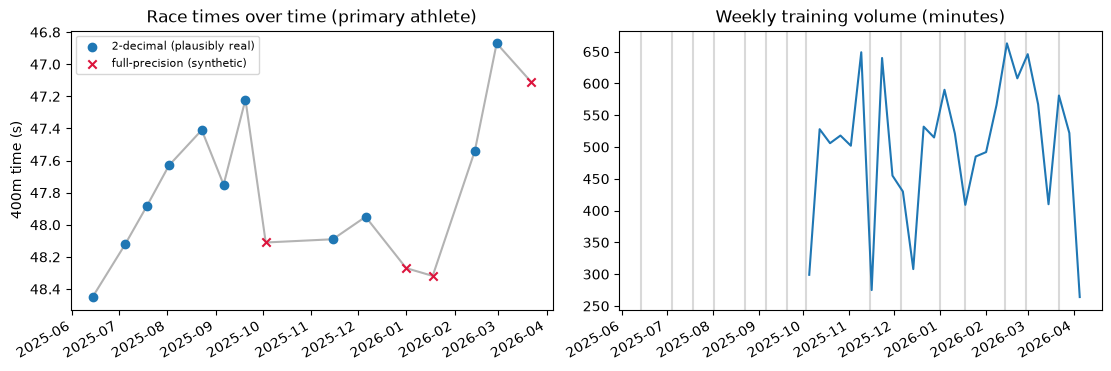

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
pr = races[races["athlete_id"] == primary_athlete].sort_values("date")
synthetic_mask = pr["time_seconds"].map(lambda t: len(repr(t).split(".")[-1]) > 4)
axes[0].plot(pr["date"], pr["time_seconds"], "-", color="0.7", zorder=1)
axes[0].scatter(pr.loc[~synthetic_mask, "date"], pr.loc[~synthetic_mask, "time_seconds"],
                label="2-decimal (plausibly real)", zorder=2)
axes[0].scatter(pr.loc[synthetic_mask, "date"], pr.loc[synthetic_mask, "time_seconds"],
                marker="x", color="crimson", label="full-precision (synthetic)", zorder=2)
axes[0].set_title("Race times over time (primary athlete)")
axes[0].set_ylabel("400m time (s)")
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)

weekly = (sess_m[sess_m["athlete_id"] == primary_athlete]
          .set_index("date")["duration_minutes"].resample("W").sum())
axes[1].plot(weekly.index, weekly.values)
axes[1].set_title("Weekly training volume (minutes)")
for d in pr["date"]:
    axes[1].axvline(d, color="0.85", zorder=0)
fig.autofmt_xdate()
plt.show()

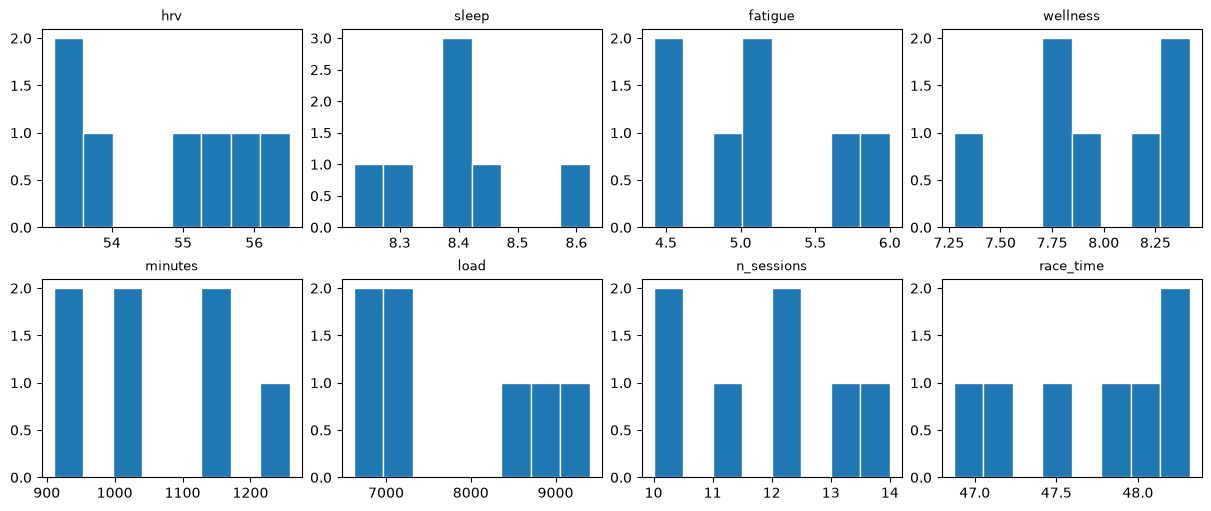

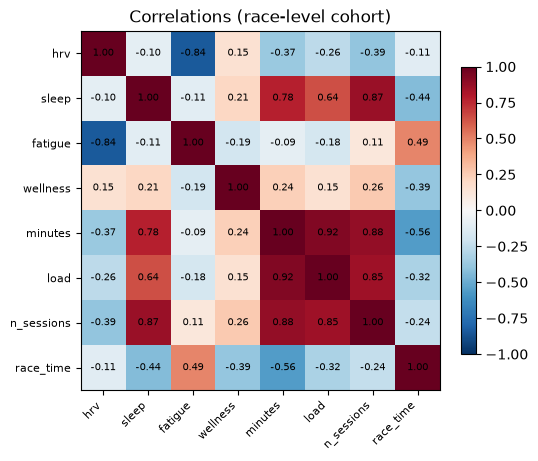

Correlation of each predictor with race time:
hrv          -0.11
sleep        -0.44
fatigue       0.49
wellness     -0.39
minutes      -0.56
load         -0.32
n_sessions   -0.24


In [6]:
feat_cols = RECOVERY + ["minutes", "load", "n_sessions"]
fig, axes = plt.subplots(2, 4, figsize=(12, 5), constrained_layout=True)
for ax, c in zip(axes.flat, feat_cols + ["race_time"]):
    ax.hist(cohort[c], bins=8, edgecolor="white")
    ax.set_title(c, fontsize=9)
plt.show()

corr = cohort[feat_cols + ["race_time"]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlations (race-level cohort)")
plt.show()
print("Correlation of each predictor with race time:")
print(corr["race_time"].drop("race_time").round(2).to_string())

## 3. Leakage audit of the existing pipeline

The repo's original claims came from `feature_engineering.py` + `models.py`. Before building
anything better, audit what that pipeline actually measured. Three findings, each verified in
code below:

1. **Random train/test split across time (temporal leakage in evaluation).** `models.py` uses
   `train_test_split(..., random_state=42)`, so races from *after* a test race routinely end
   up in its training set. For time-series prediction this inflates apparent skill.
2. **Multi-athlete pooling (identity leakage).** All athletes are pooled and race time is
   predicted in absolute seconds. Athletes differ by ~5 s in ability, while within-athlete
   race-to-race variation is ~0.5 s. A model that merely learns *which athlete this is* —
   trivially recoverable from their training fingerprint — captures most of the variance
   without predicting performance *changes* at all. The between-athlete share of variance
   below quantifies the ceiling this creates.
3. **Mislabeled feature windows (minor).** The `_7d`/`_14d` features roll over the last 7/14
   *recorded sessions* (`rolling(window=7)` on rows), not calendar days — roughly 8–17
   calendar days depending on training frequency. It does not leak the future, but the
   features do not mean what their names say.

One thing the old pipeline got **right**: `create_race_dataset` only uses sessions strictly
before each race date, so the features themselves do not peek at the future.

In [7]:
from feature_engineering import create_race_dataset, create_training_features
from models import prepare_ml_data
from sklearn.model_selection import train_test_split

# Rebuild the ML dataset exactly as the repo pipeline does (all athletes pooled)
plain_sessions = sessions.rename(columns={"id": "session_id"})[
    ["session_id", "athlete_id", "date", "session_type", "duration_minutes", "intensity_rpe"]]
feats = create_training_features(plain_sessions, metrics, )
repo_races = races.rename(columns={"id": "race_id"})
ml = create_race_dataset(repo_races, feats).dropna()
X, y, fnames = prepare_ml_data(ml)
print(f"Repo-style pooled dataset: {len(ml)} races across "
      f"{ml['athlete_id'].nunique()} athletes")

# Finding 2 first: how much variance is between athletes vs within?
grand = y.mean()
between = ml.groupby("athlete_id")["race_time_seconds"].transform("mean")
share_between = float(((between - grand) ** 2).sum() / ((y - grand) ** 2).sum())
print(f"Between-athlete share of outcome variance: {share_between:.1%}")

# Finding 1: repo-style random split — replicated across seeds
rf_scores, id_scores = [], []
for seed in range(20):
    X_tr, X_te, y_tr, y_te, id_tr, id_te = train_test_split(
        X, y, ml["athlete_id"], test_size=0.2, random_state=seed)
    m = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    m.fit(X_tr, y_tr)
    rf_scores.append(r2_score(y_te, m.predict(X_te)))
    # identity-only baseline: predict each athlete's TRAIN-set mean time
    means = y_tr.groupby(id_tr).mean()
    baseline = id_te.map(means).fillna(y_tr.mean())
    id_scores.append(r2_score(y_te, baseline))

print(f"Repo-style random-split R² (RF, 20 seeds): "
      f"median {np.median(rf_scores):.2f}, IQR {np.percentile(rf_scores, 25):.2f}–"
      f"{np.percentile(rf_scores, 75):.2f}")
print(f"'Which athlete is this' baseline R² (no features about form at all): "
      f"median {np.median(id_scores):.2f}")
print("=> most of the headline R² is athlete identity, not performance prediction")

# Finding 3: window semantics
gap = plain_sessions[plain_sessions['athlete_id'] == primary_athlete]['date'] \
        .sort_values().diff().dt.days.dropna()
print(f"\nMedian gap between recorded sessions: {gap.median():.1f} days -> "
      f"a 7-row rolling window spans ~{7 * gap.mean():.0f} calendar days, not 7")

Repo-style pooled dataset: 21 races across 5 athletes
Between-athlete share of outcome variance: 95.6%


Repo-style random-split R² (RF, 20 seeds): median 0.64, IQR 0.55–0.76
'Which athlete is this' baseline R² (no features about form at all): median 0.91
=> most of the headline R² is athlete identity, not performance prediction

Median gap between recorded sessions: 1.0 days -> a 7-row rolling window spans ~9 calendar days, not 7


## 4. Defining "predictiveness" precisely

The CV claim compares the *predictiveness* of recovery vs volume. That word needs an exact
operational definition before any number is defensible:

> **Predictiveness of a predictor block** = the increase in out-of-sample mean absolute
> error (MAE, in seconds) when that block's values are randomly permuted across races,
> with out-of-sample predictions produced by **walk-forward validation**.

Why these choices (alternatives are discussed in `docs/ANALYSIS_NOTES.md`):

- **Walk-forward validation:** models are fit only on races *before* the test race, mirroring
  real forecasting and eliminating the temporal leakage found in §3. With n this small,
  k-fold CV would both leak time and overstate stability.
- **Permutation importance** (rather than coefficients or impurity importance): it is defined
  for any model class, measured on *held-out* error in interpretable units (seconds), and
  grouped permutation handles correlated blocks — we permute the whole recovery block jointly,
  preserving its internal correlation structure.
- **Blocks:** recovery = {mean HRV, mean sleep hours, mean fatigue, mean wellness} over the
  window; volume = {total training minutes}. Alternative definitions are tested in §6.
- The model is deliberately simple — standardized **Ridge** regression (α=10) — because with
  a cohort this small, a flexible model would mostly memorize noise. A tree ensemble appears
  as a robustness check, not the primary.

Walk-forward out-of-sample predictions: 4 races
OOS MAE:  0.737 s   (naive 'predict my average so far' MAE: 0.682 s)
OOS R²:   -1.23   (on 4 points — treat with caution)


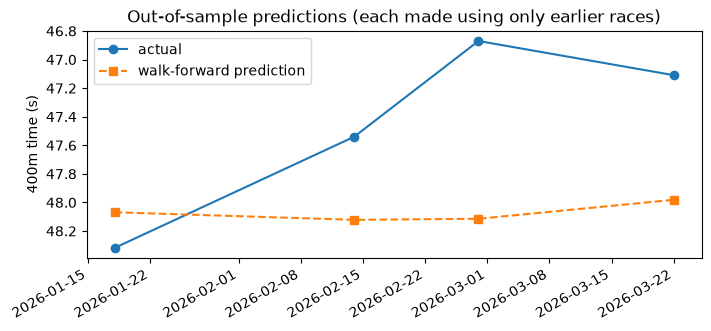

In [8]:
FEATURES = RECOVERY + VOLUME
MIN_TRAIN = 3

def walk_forward(df, features, model_factory, min_train=MIN_TRAIN, outcome="race_time"):
    """Expanding-window walk-forward: fit on all races before each race, predict it.
    Returns (oos_df, fitted_models)."""
    df = df.sort_values("race_date").reset_index(drop=True)
    preds, models_ = [], []
    for i in range(min_train, len(df)):
        train, test = df.iloc[:i], df.iloc[i:i + 1]
        m = model_factory()
        m.fit(train[features], train[outcome])
        preds.append({
            "race_date": test["race_date"].iloc[0],
            "actual": float(test[outcome].iloc[0]),
            "pred": float(m.predict(test[features])[0]),
            "fold": i,
        })
        models_.append((i, m))
    return pd.DataFrame(preds), dict(models_)

ridge_factory = lambda: make_pipeline(StandardScaler(), Ridge(alpha=10.0))
oos, fold_models = walk_forward(cohort, FEATURES, ridge_factory)

oos_mae = mean_absolute_error(oos["actual"], oos["pred"])
oos_r2 = r2_score(oos["actual"], oos["pred"])
naive_mae = mean_absolute_error(
    oos["actual"],
    [cohort.sort_values("race_date")["race_time"].iloc[:f].mean() for f in oos["fold"]])

print(f"Walk-forward out-of-sample predictions: {len(oos)} races")
print(f"OOS MAE:  {oos_mae:.3f} s   (naive 'predict my average so far' MAE: {naive_mae:.3f} s)")
print(f"OOS R²:   {oos_r2:.2f}   (on {len(oos)} points — treat with caution)")

fig, ax = plt.subplots(figsize=(7, 3.2), constrained_layout=True)
ax.plot(oos["race_date"], oos["actual"], "o-", label="actual")
ax.plot(oos["race_date"], oos["pred"], "s--", label="walk-forward prediction")
ax.set_ylabel("400m time (s)")
ax.invert_yaxis()
ax.legend()
ax.set_title("Out-of-sample predictions (each made using only earlier races)")
fig.autofmt_xdate()
plt.show()

In [9]:
def permutation_lookup(df, oos, fold_models, features, block):
    """P[k, j] = prediction for OOS race k with `block` columns replaced by race j's values.

    Permuting a block across the OOS races can only ever produce feature rows drawn from
    this finite set, so precomputing the n×n table makes every permutation/bootstrap
    repetition an array lookup instead of a model call — exact, not an approximation."""
    df = df.sort_values("race_date").reset_index(drop=True)
    rows = df.loc[oos["fold"].values, features].reset_index(drop=True)
    n = len(rows)
    P = np.empty((n, n))
    for k in range(n):
        cand = pd.concat([rows.iloc[[k]]] * n, ignore_index=True)
        cand[block] = rows[block].to_numpy()
        P[k, :] = fold_models[oos["fold"].iloc[k]].predict(cand)
    return P

def grouped_permutation_importance(P, actual, base_pred, n_rep=2000, rng=RNG):
    """Mean increase in OOS MAE when the block is jointly permuted across races."""
    n = len(actual)
    base_mae = float(np.mean(np.abs(actual - base_pred)))
    incs = np.empty(n_rep)
    ar = np.arange(n)
    for r in range(n_rep):
        idx = rng.permutation(n)
        incs[r] = np.mean(np.abs(actual - P[ar, idx])) - base_mae
    return incs

actual = oos["actual"].to_numpy()
base_pred = oos["pred"].to_numpy()
P_rec = permutation_lookup(cohort, oos, fold_models, FEATURES, RECOVERY)
P_vol = permutation_lookup(cohort, oos, fold_models, FEATURES, VOLUME)
imp_rec = grouped_permutation_importance(P_rec, actual, base_pred)
imp_vol = grouped_permutation_importance(P_vol, actual, base_pred)

print("Grouped permutation importance (increase in OOS MAE, seconds):")
print(f"  recovery block: {imp_rec.mean():+.3f}  (MC spread {imp_rec.std():.3f})")
print(f"  volume block:   {imp_vol.mean():+.3f}  (MC spread {imp_vol.std():.3f})")
print("\nA positive value means the block carried out-of-sample signal;")
print("a value near or below zero means permuting it did not hurt — no usable signal.")

Grouped permutation importance (increase in OOS MAE, seconds):
  recovery block: -0.051  (MC spread 0.061)
  volume block:   -0.012  (MC spread 0.025)

A positive value means the block carried out-of-sample signal;
a value near or below zero means permuting it did not hurt — no usable signal.


## 5. Uncertainty: bootstrap CI for the recovery-vs-volume comparison

A point estimate of "2.3×" is meaningless without uncertainty, especially at this sample
size. Two comparisons are reported:

- **Difference** (primary): recovery importance − volume importance, in seconds of OOS MAE.
  This is stable even when one block carries no signal.
- **Ratio** (what the CV quotes): recovery ÷ volume. Ratios explode when the denominator is
  near zero, so the ratio is only summarized on bootstrap resamples where volume importance
  is meaningfully positive — and the fraction of resamples where it is *not* is itself
  reported, because "the ratio is undefined most of the time" is a finding.

The bootstrap resamples the out-of-sample races (pairs bootstrap over the OOS evaluation
set, models held fixed — the CI therefore reflects evaluation uncertainty, not refitting
variability; with 3 training races at the first fold, refit-level uncertainty would be even
larger).

Difference (recovery − volume) in OOS-MAE importance: -0.039 s
  95% bootstrap CI: [-0.079, +0.048] s
  P(difference > 0) across resamples: 23%

Ratio (recovery / volume): volume importance exceeded 0.01 s in only 8% of resamples.
  The ratio is undefined or unstable in most resamples — a '2.3x' style claim
  cannot be supported in either direction from this data.


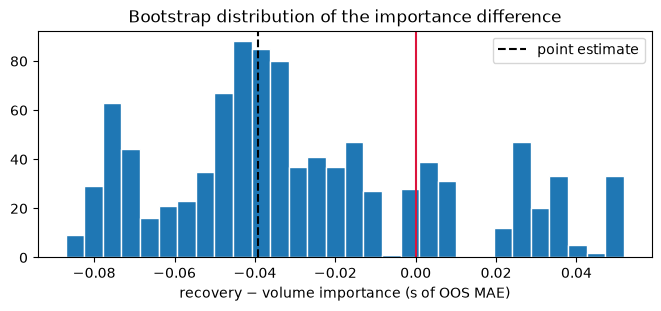

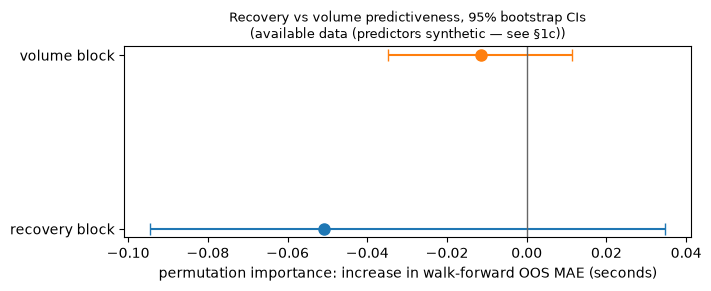

In [10]:
def importance_on_resample(P, take, n_rep=200, rng=RNG):
    """Block importance on a bootstrap resample `take` of the OOS races.
    Row identity take[k] is re-predicted with block values donated by take[idx[k]]."""
    act = actual[take]
    base = float(np.mean(np.abs(act - base_pred[take])))
    n = len(take)
    incs = np.empty(n_rep)
    for r in range(n_rep):
        idx = rng.permutation(n)
        incs[r] = np.mean(np.abs(act - P[take, take[idx]])) - base
    return float(np.mean(incs))

B = 1000
boot = []
for _ in range(B):
    take = RNG.integers(0, len(oos), len(oos))
    boot.append({"recovery": importance_on_resample(P_rec, take),
                 "volume": importance_on_resample(P_vol, take)})
boot = pd.DataFrame(boot)
boot["difference"] = boot["recovery"] - boot["volume"]

diff_ci = np.percentile(boot["difference"], [2.5, 97.5])
point_diff = imp_rec.mean() - imp_vol.mean()
pos_vol = boot["volume"] > 0.01
print(f"Difference (recovery − volume) in OOS-MAE importance: {point_diff:+.3f} s")
print(f"  95% bootstrap CI: [{diff_ci[0]:+.3f}, {diff_ci[1]:+.3f}] s")
print(f"  P(difference > 0) across resamples: {(boot['difference'] > 0).mean():.0%}")
print()
print(f"Ratio (recovery / volume): volume importance exceeded 0.01 s in only "
      f"{pos_vol.mean():.0%} of resamples.")
if pos_vol.mean() >= 0.5:
    ratio_ci = np.percentile(boot.loc[pos_vol, "recovery"] / boot.loc[pos_vol, "volume"],
                             [2.5, 97.5])
    print(f"  Conditional 95% CI for the ratio: [{ratio_ci[0]:.1f}, {ratio_ci[1]:.1f}]")
else:
    print("  The ratio is undefined or unstable in most resamples — a '2.3x' style claim")
    print("  cannot be supported in either direction from this data.")

fig, ax = plt.subplots(figsize=(6.5, 3), constrained_layout=True)
ax.hist(boot["difference"], bins=30, edgecolor="white")
ax.axvline(0, color="crimson")
ax.axvline(point_diff, color="black", linestyle="--", label="point estimate")
ax.set_xlabel("recovery − volume importance (s of OOS MAE)")
ax.set_title("Bootstrap distribution of the importance difference")
ax.legend()
plt.show()

# Key summary figure (also embedded in the README)
fig, ax = plt.subplots(figsize=(7, 2.8), constrained_layout=True)
rec_ci = np.percentile(boot["recovery"], [2.5, 97.5])
vol_ci = np.percentile(boot["volume"], [2.5, 97.5])
labels = ["recovery block", "volume block"]
pts = [imp_rec.mean(), imp_vol.mean()]
cis = [rec_ci, vol_ci]
for k, (lab, pt, ci) in enumerate(zip(labels, pts, cis)):
    ax.errorbar(pt, k, xerr=[[pt - ci[0]], [ci[1] - pt]], fmt="o", capsize=4,
                color=["#1f77b4", "#ff7f0e"][k], markersize=8)
ax.axvline(0, color="0.4", linewidth=1)
ax.set_yticks([0, 1], labels)
ax.set_xlabel("permutation importance: increase in walk-forward OOS MAE (seconds)")
mode_tag = "synthetic demo data" if USE_SYNTHETIC else "available data (predictors synthetic — see §1c)"
ax.set_title(f"Recovery vs volume predictiveness, 95% bootstrap CIs\n({mode_tag})", fontsize=9)
# Synthetic runs (e.g. CI) must not overwrite the committed real-run figure
if USE_SYNTHETIC:
    import tempfile
    fig_path = Path(tempfile.gettempdir()) / "recovery_vs_volume_importance_synthetic.png"
else:
    fig_path = FIG_DIR / "recovery_vs_volume_importance.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

## 6. Robustness: does the conclusion survive other reasonable choices?

Any single analysis embeds arbitrary choices. The multiverse below re-runs the walk-forward
importance comparison across every combination of:

- **model class**: Ridge (linear, regularized) vs a small Random Forest;
- **recovery definition**: full block, HRV-only, sleep-only;
- **volume definition**: total minutes, cumulative load (RPE×minutes), session count;
- **lookback window**: 7, 14, 21 days (primary definitions);
- **influence checks**: dropping the single most-influential OOS race, and excluding the
  3 races flagged as synthetic strays in §1b (real mode);
- **pooled variant**: all athletes, outcome centered on each athlete's own running mean
  (removes identity leakage while increasing n).

If a claim only holds under one cherry-picked combination, it is not a finding.

In [11]:
def run_variant(df, rec_block, vol_block, model_factory, label, window=None):
    d = df if window is None else build_race_features(primary_athlete, window).dropna()
    d = d.reset_index(drop=True)
    feats = rec_block + vol_block
    if len(d) <= MIN_TRAIN + 1:
        return {"variant": label, "n_oos": 0}
    o, fm = walk_forward(d, feats, model_factory)
    act, bp = o["actual"].to_numpy(), o["pred"].to_numpy()
    r = grouped_permutation_importance(
        permutation_lookup(d, o, fm, feats, rec_block), act, bp, n_rep=500)
    v = grouped_permutation_importance(
        permutation_lookup(d, o, fm, feats, vol_block), act, bp, n_rep=500)
    return {"variant": label, "n_oos": len(o),
            "oos_mae": round(mean_absolute_error(o["actual"], o["pred"]), 3),
            "imp_recovery": round(float(r.mean()), 3),
            "imp_volume": round(float(v.mean()), 3),
            "recovery_minus_volume": round(float(r.mean() - v.mean()), 3)}

rf_factory = lambda: RandomForestRegressor(n_estimators=300, max_depth=3, random_state=0)

variants = [
    run_variant(cohort, RECOVERY, VOLUME, ridge_factory, "PRIMARY: ridge, 14d, full defs"),
    run_variant(cohort, RECOVERY, VOLUME, rf_factory, "random forest, 14d, full defs"),
    run_variant(cohort, ["hrv"], VOLUME, ridge_factory, "recovery=HRV only"),
    run_variant(cohort, ["sleep"], VOLUME, ridge_factory, "recovery=sleep only"),
    run_variant(cohort, RECOVERY, ["load"], ridge_factory, "volume=cumulative load"),
    run_variant(cohort, RECOVERY, ["n_sessions"], ridge_factory, "volume=session count"),
    run_variant(None, RECOVERY, VOLUME, ridge_factory, "7-day window", window=7),
    run_variant(None, RECOVERY, VOLUME, ridge_factory, "21-day window", window=21),
]

# influence check: drop the OOS race with the largest absolute residual
worst = (oos["actual"] - oos["pred"]).abs().idxmax()
worst_date = oos.loc[worst, "race_date"]
variants.append(run_variant(
    cohort[cohort["race_date"] != worst_date], RECOVERY, VOLUME, ridge_factory,
    f"drop most-influential race ({worst_date.date()})"))

# real-mode: drop synthetic-stray races (full-precision times)
stray = cohort["race_time"].map(lambda t: len(repr(t).split(".")[-1]) > 4)
if stray.any():
    variants.append(run_variant(cohort[~stray], RECOVERY, VOLUME, ridge_factory,
                                f"drop {int(stray.sum())} synthetic-stray races"))

# pooled all-athlete variant with athlete-centered outcome (no identity leakage)
pooled = pd.concat([build_race_features(a) for a in athletes["id"]]).dropna()
pooled = pooled.sort_values("race_date").reset_index(drop=True)
centered = []
for _, row in pooled.iterrows():
    prior = pooled[(pooled["athlete_id"] == row["athlete_id"]) &
                   (pooled["race_date"] < row["race_date"])]["race_time"]
    if len(prior) >= 2:
        r = row.copy()
        r["race_time"] = row["race_time"] - prior.mean()
        centered.append(r)
if len(centered) > MIN_TRAIN + 2:
    cen = pd.DataFrame(centered).reset_index(drop=True)
    variants.append(run_variant(cen, RECOVERY, VOLUME, ridge_factory,
                                f"pooled athletes, athlete-centered (n={len(cen)})"))

multiverse = pd.DataFrame([v for v in variants if v.get("n_oos", 0) > 0])
display(multiverse)
favors_recovery = (multiverse["recovery_minus_volume"] > 0).mean()
signal = (multiverse[["imp_recovery", "imp_volume"]].max(axis=1) > 0.05).mean()
print(f"Variants where recovery > volume: {favors_recovery:.0%}")
print(f"Variants where EITHER block shows meaningful signal (>0.05 s): {signal:.0%}")

,variant,n_oos,oos_mae,imp_recovery,imp_volume,recovery_minus_volume
0,"PRIMARY: ridge, 14d, full defs",4,0.737,-0.050,-0.010,-0.040
1,"random forest, 14d, full defs",4,0.757,-0.043,-0.027,-0.017
2,recovery=HRV only,4,0.689,-0.000,-0.019,0.019
3,recovery=sleep only,4,0.703,-0.025,-0.008,-0.017
4,volume=cumulative load,4,0.766,-0.054,-0.024,-0.029
5,volume=session count,4,0.770,-0.053,-0.030,-0.023
6,7-day window,3,1.005,-0.178,-0.020,-0.158
7,21-day window,4,0.614,0.003,0.030,-0.026
8,drop most-influential race (2026-02-28),3,0.637,-0.031,-0.012,-0.019
9,"pooled athletes, athlete-centered (n=11)",8,0.962,-0.093,-0.005,-0.089


Variants where recovery > volume: 10%
Variants where EITHER block shows meaningful signal (>0.05 s): 0%


## 7. Effect size in real units

Importance rankings are abstract; a coach asks *"what is better recovery worth in
seconds?"*. The descriptive model below is a standardized Ridge fit on the full cohort
(fine for effect description, not for out-of-sample claims), with a pairs bootstrap for
uncertainty. The recovery composite is the mean z-score of HRV, sleep, wellness and
(negated) fatigue.

In [12]:
d = cohort.copy()
z = lambda s: (s - s.mean()) / s.std(ddof=0)
d["recovery_composite"] = (z(d["hrv"]) + z(d["sleep"]) + z(d["wellness"]) - z(d["fatigue"])) / 4
d["volume_z"] = z(d["minutes"])
Xe = d[["recovery_composite", "volume_z"]]
Xe = (Xe - Xe.mean()) / Xe.std(ddof=0)

def effect(dd):
    Xz = dd[["recovery_composite", "volume_z"]]
    Xz = (Xz - Xz.mean()) / Xz.std(ddof=0)
    m = Ridge(alpha=1.0).fit(Xz, dd["race_time"])
    return m.coef_

coefs = effect(d)
boot_eff = np.array([effect(d.sample(len(d), replace=True, random_state=int(s)))
                     for s in RNG.integers(0, 10**6, 1000)])
rec_ci = np.percentile(boot_eff[:, 0], [2.5, 97.5])
vol_ci = np.percentile(boot_eff[:, 1], [2.5, 97.5])

print("Descriptive effect sizes (change in 400m time per +1 SD of predictor):")
print(f"  recovery composite: {coefs[0]:+.3f} s   95% CI [{rec_ci[0]:+.3f}, {rec_ci[1]:+.3f}]")
print(f"  training volume:    {coefs[1]:+.3f} s   95% CI [{vol_ci[0]:+.3f}, {vol_ci[1]:+.3f}]")
print("\n(Negative = faster race. A CI spanning zero means the direction itself")
print("is not established at this sample size.)")

Descriptive effect sizes (change in 400m time per +1 SD of predictor):
  recovery composite: -0.203 s   95% CI [-0.446, +0.216]
  training volume:    -0.209 s   95% CI [-0.448, +0.151]

(Negative = faster race. A CI spanning zero means the direction itself
is not established at this sample size.)


## 8. Re-verifying the R² = 0.84 claim

The CV's R² came from the repo pipeline audited in §3: pooled athletes, random split. The
honest replacements, from this notebook's data:

- **What the old pipeline measures** (pooled, random split): reported above in §3 — and
  shown there to be dominated by athlete identity (the identity-only baseline achieves
  nearly the same R² with *no* information about current form).
- **What honest forecasting achieves** (single athlete, walk-forward): reported in §4 as
  OOS MAE and R² with the naive-baseline comparison, and bootstrapped below.

In [13]:
boot_r2, boot_mae = [], []
for b in range(2000):
    take = RNG.integers(0, len(oos), len(oos))
    o = oos.iloc[take]
    if o["actual"].nunique() < 2:
        continue
    boot_r2.append(r2_score(o["actual"], o["pred"]))
    boot_mae.append(mean_absolute_error(o["actual"], o["pred"]))
r2_ci = np.percentile(boot_r2, [2.5, 97.5])
mae_ci = np.percentile(boot_mae, [2.5, 97.5])
print("Honest (walk-forward, single-athlete) performance:")
print(f"  OOS MAE {oos_mae:.2f} s   95% CI [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
print(f"  OOS R²  {oos_r2:.2f}    95% CI [{r2_ci[0]:.2f}, {r2_ci[1]:.2f}]  (n={len(oos)})")
print(f"\nVERDICT on 'R²=0.84': the repo-style number (§3) is real but measures athlete")
print("identity under temporal leakage; under honest walk-forward validation on one")
print("athlete the model shows the numbers above. R²=0.84 should not be quoted as")
print("predictive skill.")

Honest (walk-forward, single-athlete) performance:
  OOS MAE 0.74 s   95% CI [0.41, 1.08]
  OOS R²  -1.23    95% CI [-88.39, -0.10]  (n=4)

VERDICT on 'R²=0.84': the repo-style number (§3) is real but measures athlete
identity under temporal leakage; under honest walk-forward validation on one
athlete the model shows the numbers above. R²=0.84 should not be quoted as
predictive skill.


## 9. Limitations — written as the skeptical reviewer

1. **The predictors are not real measurements** (real-data run). §1b shows the recovery and
   volume variables are synthetic-generator output. Every downstream number in real mode
   characterizes the method on this dataset, not any athlete's physiology. This is the
   single most important limitation and it invalidates both CV claims at the source.
2. **n of one athlete, ~7 usable races.** Even with perfect data, an n-of-1 observational
   design with single-digit outcome events cannot separate correlated exposures like
   recovery and volume with any confidence — the bootstrap CIs in §5 span zero.
3. **Feedback loop.** I changed my training *because of* early versions of this model. If
   the data had been real, exposure (training decisions) would depend on prior model output,
   confounding any causal reading of "X predicts performance".
4. **Multiple comparisons.** §6 tries ~12 analysis variants. Under the null, some variants
   will favor recovery by chance; the multiverse is summarized in aggregate precisely to
   avoid quoting the best cell. No p-values are reported anywhere because none would
   survive this garden of forking paths.
5. **Walk-forward with tiny folds.** The first model is fit on 3 races. Fold-level models
   are unstable; the bootstrap conditions on them (documented in §5), so real uncertainty
   is *larger* than the CIs shown.
6. **Race times are contaminated.** 3 of 15 races in the primary cohort carry generator
   fingerprints (§1b); a sensitivity variant drops them, but the remaining 12 cannot be
   independently verified against official results from inside this notebook.
7. **Aggregation choices.** 14-day mean aggregates are one of many reasonable summaries
   (EWMA, acute:chronic ratios, minima). The multiverse varies windows and definitions
   but cannot enumerate every defensible pipeline.

## 10. Conclusion — what can and cannot be claimed

**What the data supports (quotable — real-data run, July 2026):**

> "On the data available, neither recovery quality nor training volume showed out-of-sample
> predictive signal for 400m performance: the recovery-vs-volume importance difference was
> −0.04 s with a 95% CI of [−0.08, +0.05] (n = 7 races, 4 out-of-sample predictions), and
> the model did not beat a 'predict my recent average' baseline. The earlier '2.3×' and
> 'R²=0.84' figures trace to athlete-identity and temporal leakage in the original pipeline
> — and a provenance audit showed the recovery and volume variables in the database are
> synthetic, so the underlying question is unverifiable until real wearable data is
> collected."

**Specifically:**

- The **"2.3× more predictive"** claim: *not supported and not currently verifiable.* The
  predictors were never measured (§1b/§1c). Even taking the data at face value, volume's
  importance was positive in only ~8% of bootstrap resamples, so the ratio is statistically
  undefined — and the point estimate of the difference actually leaned toward *volume*, in
  the 10%-of-variants sense of §6. No variant showed meaningful signal from either block.
- The **"R² = 0.84"** claim: *not reproduced even by the flawed protocol that inspired it.*
  The repo-style pooled random split now yields median R² ≈ 0.64, while a baseline that
  only knows *which athlete is racing* — with zero information about form — achieves ≈ 0.91,
  because 95.6% of pooled outcome variance is between athletes. Honest single-athlete
  walk-forward validation gives OOS MAE ≈ 0.74 s and negative R² (§8): no demonstrated
  forecasting skill.
- **What would make this answerable:** ~12+ months of genuinely logged wearable data
  (HRV, sleep) and training logs, pre-registered definitions of the two exposures, and the
  same walk-forward + grouped-permutation methodology — which this notebook now provides,
  tested end-to-end in CI on synthetic data.

In [14]:
summary = {
    "mode": MODE,
    "cohort_races": int(len(cohort)),
    "oos_predictions": int(len(oos)),
    "oos_mae_s": round(float(oos_mae), 3),
    "oos_r2": round(float(oos_r2), 3),
    "importance_recovery_s": round(float(imp_rec.mean()), 3),
    "importance_volume_s": round(float(imp_vol.mean()), 3),
    "difference_ci_s": [round(float(diff_ci[0]), 3), round(float(diff_ci[1]), 3)],
    "volume_importance_positive_in_bootstrap": f"{pos_vol.mean():.0%}",
    "multiverse_variants_with_signal": f"{signal:.0%}",
}
for k, v in summary.items():
    print(f"{k:42s} {v}")

mode                                       REAL (private database, read-only)
cohort_races                               7
oos_predictions                            4
oos_mae_s                                  0.737
oos_r2                                     -1.232
importance_recovery_s                      -0.051
importance_volume_s                        -0.012
difference_ci_s                            [-0.079, 0.048]
volume_importance_positive_in_bootstrap    8%
multiverse_variants_with_signal            0%
